### Agenda
EDA-Info,shape

Handling Missing Values

Handling Outliers

Handling Skewness

Data Encoding

Feature Scaling -Normalization and Standardization

Feature Engineering

### Exploratory Data Analysis (EDA)

- Exploratory Data Analysis (EDA) is a critical step in the data analysis process, aimed at understanding the underlying patterns, relationships, and structure of the dataset. It involves visualizing and summarizing key characteristics of the data, often using statistical graphics, plots, and other data visualization tools. EDA helps in identifying anomalies, trends, patterns, and potential areas for further analysis

### Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Read and Understand Data

In [2]:
# reading file
df = pd.read_csv('cars.csv')

In [3]:
# read first few rows
df.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,13495
1,3,?,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,16500
2,1,?,alfa-romero,gas,hatchback,rwd,front,65.5,52.4,ohcv,152,154,19,26,16500
3,2,164,audi,gas,sedan,fwd,front,66.2,54.3,ohc,109,102,24,30,13950
4,2,164,audi,gas,sedan,4wd,front,66.4,54.3,ohc,136,115,18,22,17450


In [4]:
# read last few rows
df.tail()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
200,-1,95,volvo,gas,sedan,rwd,front,68.9,55.5,ohc,141,114,23,28,16845
201,-1,95,volvo,gas,sedan,rwd,front,68.8,55.5,ohc,141,160,19,25,19045
202,-1,95,volvo,gas,sedan,rwd,front,68.9,55.5,ohcv,173,134,18,23,21485
203,-1,95,volvo,diesel,sedan,rwd,front,68.9,55.5,ohc,145,106,26,27,22470
204,-1,95,volvo,gas,sedan,rwd,front,68.9,55.5,ohc,141,114,19,25,22625


In [5]:
# random few rows
df.sample(5)

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
94,1,128,nissan,gas,sedan,fwd,front,63.8,54.5,ohc,97,69,31,37,7299
85,1,125,mitsubishi,gas,sedan,fwd,front,65.4,51.6,ohc,122,88,25,32,6989
11,0,192,bmw,gas,sedan,rwd,front,64.8,54.3,ohc,108,101,23,29,16925
76,2,161,mitsubishi,gas,hatchback,fwd,front,64.4,50.8,ohc,92,68,37,41,5389
113,0,?,peugot,gas,wagon,rwd,front,68.4,56.7,l,120,95,19,24,16695


In [6]:
# shape of dataset
df.shape

(205, 15)

In [ ]:
# Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   body-style         205 non-null    object 
 5   drive-wheels       205 non-null    object 
 6   engine-location    205 non-null    object 
 7   width              205 non-null    float64
 8   height             205 non-null    float64
 9   engine-type        205 non-null    object 
 10  engine-size        205 non-null    int64  
 11  horsepower         205 non-null    object 
 12  city-mpg           205 non-null    int64  
 13  highway-mpg        205 non-null    int64  
 14  price              205 non-null    int64  
dtypes: float64(2), int64(5), object(8)
memory usage: 24.2+ KB


In [ ]:
# checking a unique values for each columns
def unique_values(cols):
    for i in cols:
        print(f"{i} column unique values: {df[i].unique()}")
        print('-'*120)
        print()

cols = df.columns
unique_values(cols)

symboling column unique values: [ 3  1  2  0 -1 -2]
------------------------------------------------------------------------------------------------------------------------

normalized-losses column unique values: ['?' '164' '158' '192' '188' '121' '98' '81' '118' '148' '110' '145' '137'
 '101' '78' '106' '85' '107' '104' '113' '150' '129' '115' '93' '142'
 '161' '153' '125' '128' '122' '103' '168' '108' '194' '231' '119' '154'
 '74' '186' '83' '102' '89' '87' '77' '91' '134' '65' '197' '90' '94'
 '256' '95']
------------------------------------------------------------------------------------------------------------------------

make column unique values: ['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan' 'peugot'
 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen'
 'volvo']
---------------------------------------------------------------------------------------------------------------------

In [ ]:
# Describe
df.describe()

,symboling,width,height,engine-size,city-mpg,highway-mpg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,65.907805,53.724878,126.907317,25.219512,30.751220,13227.478049
std,1.245307,2.145204,2.443522,41.642693,6.542142,6.886443,7902.651615
min,-2.000000,60.300000,47.800000,61.000000,13.000000,16.000000,5118.000000
25%,0.000000,64.100000,52.000000,97.000000,19.000000,25.000000,7788.000000
50%,1.000000,65.500000,54.100000,120.000000,24.000000,30.000000,10345.000000
75%,2.000000,66.900000,55.500000,141.000000,30.000000,34.000000,16500.000000
max,3.000000,72.300000,59.800000,326.000000,49.000000,54.000000,45400.000000


In [ ]:
# df.duplicated()
df.duplicated().sum()

np.int64(0)

In [ ]:
# null values
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
body-style           0
drive-wheels         0
engine-location      0
width                0
height               0
engine-type          0
engine-size          0
horsepower           0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

### What you Understand about your dataset
- In dataset contain 205 rows and 15 columns
- In some columns we have unknown value `?`
- there is no duplicates values are present

- Note: need to clean (deal with unknown values columns) to Understand more about this data.

### Handling Missing Data

- Missing data refers to the absence of values for certain features in a dataset. This can occur due to various reasons such as data collection errors, incorrect data entry, or non-responses in surveys.

##### Common strategies for handling missing values include:

- Deletion: Removing rows or columns with missing values, though this can lead to information loss.
  
- Imputation: Filling missing values with statistical measures like the mean, median, or mode of the feature, or using more sophisticated techniques like regression or KNN imputation.

- Purpose: Handling missing data is crucial because most machine learning algorithms cannot process missing values directly, and improper handling can lead to inaccurate or biased results.

In [ ]:
# handling normalized-losses column
'''
1. replace '?' with np.nan
2. change the datatype of column
3. checking distribution to imputation
  - if the data is skweed calculate median else mean
4. impute a nan with respective central tendency value
'''
print(df['normalized-losses'].unique())

['?' '164' '158' '192' '188' '121' '98' '81' '118' '148' '110' '145' '137'
 '101' '78' '106' '85' '107' '104' '113' '150' '129' '115' '93' '142'
 '161' '153' '125' '128' '122' '103' '168' '108' '194' '231' '119' '154'
 '74' '186' '83' '102' '89' '87' '77' '91' '134' '65' '197' '90' '94'
 '256' '95']


In [14]:
# 1. replace '?' with np.nan
df['normalized-losses'] = df['normalized-losses'].replace('?',np.nan)

In [15]:
# checing replacement is done or not
print(df['normalized-losses'].unique())

[nan '164' '158' '192' '188' '121' '98' '81' '118' '148' '110' '145' '137'
 '101' '78' '106' '85' '107' '104' '113' '150' '129' '115' '93' '142'
 '161' '153' '125' '128' '122' '103' '168' '108' '194' '231' '119' '154'
 '74' '186' '83' '102' '89' '87' '77' '91' '134' '65' '197' '90' '94'
 '256' '95']


In [17]:
# 2. change the datatype of column
df['normalized-losses'] = df['normalized-losses'].astype(float)

In [18]:
# checing replacement is done or not
print(df['normalized-losses'].unique())

[ nan 164. 158. 192. 188. 121.  98.  81. 118. 148. 110. 145. 137. 101.
  78. 106.  85. 107. 104. 113. 150. 129. 115.  93. 142. 161. 153. 125.
 128. 122. 103. 168. 108. 194. 231. 119. 154.  74. 186.  83. 102.  89.
  87.  77.  91. 134.  65. 197.  90.  94. 256.  95.]


<Axes: xlabel='normalized-losses', ylabel='Density'>

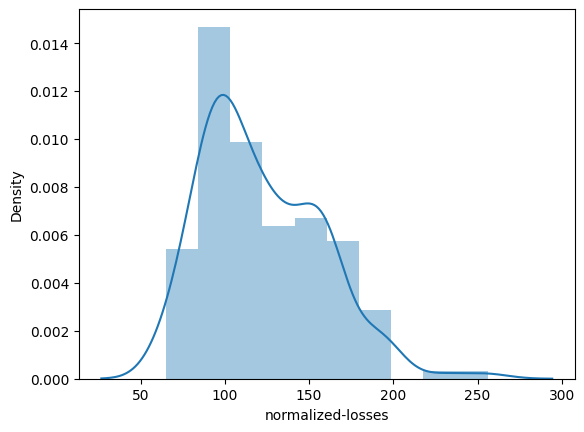

In [20]:
# 3. checking distribution to imputation
sns.distplot(df['normalized-losses'])

In [ ]:
df.describe()

,symboling,normalized-losses,width,height,engine-size,city-mpg,highway-mpg,price
count,205.000000,164.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,122.000000,65.907805,53.724878,126.907317,25.219512,30.751220,13227.478049
std,1.245307,35.442168,2.145204,2.443522,41.642693,6.542142,6.886443,7902.651615
min,-2.000000,65.000000,60.300000,47.800000,61.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,64.100000,52.000000,97.000000,19.000000,25.000000,7788.000000
50%,1.000000,115.000000,65.500000,54.100000,120.000000,24.000000,30.000000,10345.000000
75%,2.000000,150.000000,66.900000,55.500000,141.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,72.300000,59.800000,326.000000,49.000000,54.000000,45400.000000


In [ ]:
'''
As we see Distribution is right skweed so we have to impute with median
'''
df.isnull().sum()

symboling             0
normalized-losses    41
make                  0
fuel-type             0
body-style            0
drive-wheels          0
engine-location       0
width                 0
height                0
engine-type           0
engine-size           0
horsepower            0
city-mpg              0
highway-mpg           0
price                 0
dtype: int64

In [24]:
# calculate median for impute
normalized_losses_median = df['normalized-losses'].median()
normalized_losses_median

115.0

In [22]:
# 4. impute a nan with respective central tendency value
df['normalized-losses'].fillna(normalized_losses_median,inplace=True)

In [23]:
# checking nan values are imputed or not
print(df['normalized-losses'].unique())

[115. 164. 158. 192. 188. 121.  98.  81. 118. 148. 110. 145. 137. 101.
  78. 106.  85. 107. 104. 113. 150. 129.  93. 142. 161. 153. 125. 128.
 122. 103. 168. 108. 194. 231. 119. 154.  74. 186.  83. 102.  89.  87.
  77.  91. 134.  65. 197.  90.  94. 256.  95.]


In [25]:
# checking null values
df.isnull().sum()

,0
symboling,0
normalized-losses,0
make,0
fuel-type,0
body-style,0
drive-wheels,0
engine-location,0
width,0
height,0
engine-type,0


In [26]:
# handling horsepower column
'''
1. replace '?' with np.nan
2. change the datatype of column
3. checking distribution to imputation
  - if the data is skweed calculate median else mean
4. impute a nan with respective central tendency value
'''
print(df['horsepower'].unique())

['111' '154' '102' '115' '110' '140' '160' '101' '121' '182' '48' '70'
 '68' '88' '145' '58' '76' '60' '86' '100' '78' '90' '176' '262' '135'
 '84' '64' '120' '72' '123' '155' '184' '175' '116' '69' '55' '97' '152'
 '200' '95' '142' '143' '207' '288' '?' '73' '82' '94' '62' '56' '112'
 '92' '161' '156' '52' '85' '114' '162' '134' '106']


In [27]:
# 1. replace '?' with np.nan
df['horsepower'] = df['horsepower'].replace('?',np.nan)

In [28]:
# checing replacement is done or not
print(df['horsepower'].unique())

['111' '154' '102' '115' '110' '140' '160' '101' '121' '182' '48' '70'
 '68' '88' '145' '58' '76' '60' '86' '100' '78' '90' '176' '262' '135'
 '84' '64' '120' '72' '123' '155' '184' '175' '116' '69' '55' '97' '152'
 '200' '95' '142' '143' '207' '288' nan '73' '82' '94' '62' '56' '112'
 '92' '161' '156' '52' '85' '114' '162' '134' '106']


In [29]:
# 2. change the datatype of column
df['horsepower'] = df['horsepower'].astype(float)

In [30]:
# checing replacement is done or not
print(df['horsepower'].unique())

[111. 154. 102. 115. 110. 140. 160. 101. 121. 182.  48.  70.  68.  88.
 145.  58.  76.  60.  86. 100.  78.  90. 176. 262. 135.  84.  64. 120.
  72. 123. 155. 184. 175. 116.  69.  55.  97. 152. 200.  95. 142. 143.
 207. 288.  nan  73.  82.  94.  62.  56. 112.  92. 161. 156.  52.  85.
 114. 162. 134. 106.]


<Axes: xlabel='horsepower', ylabel='Density'>

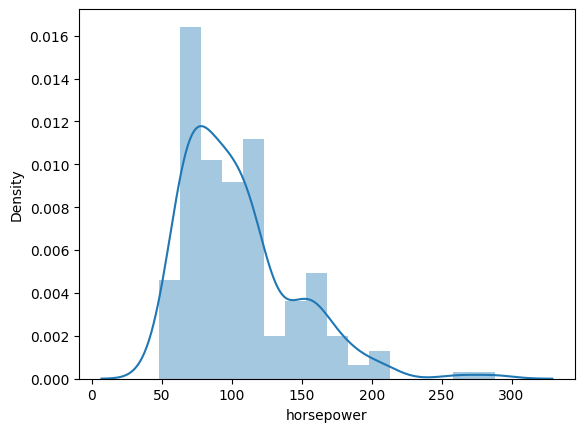

In [31]:
# 3. checking distribution to imputation
sns.distplot(df['horsepower'])

In [32]:
df.describe()

,symboling,normalized-losses,width,height,engine-size,horsepower,city-mpg,highway-mpg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,203.000000,205.000000,205.000000,205.000000
mean,0.834146,120.600000,65.907805,53.724878,126.907317,104.256158,25.219512,30.751220,13227.478049
std,1.245307,31.805105,2.145204,2.443522,41.642693,39.714369,6.542142,6.886443,7902.651615
min,-2.000000,65.000000,60.300000,47.800000,61.000000,48.000000,13.000000,16.000000,5118.000000
25%,0.000000,101.000000,64.100000,52.000000,97.000000,70.000000,19.000000,25.000000,7788.000000
50%,1.000000,115.000000,65.500000,54.100000,120.000000,95.000000,24.000000,30.000000,10345.000000
75%,2.000000,137.000000,66.900000,55.500000,141.000000,116.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,72.300000,59.800000,326.000000,288.000000,49.000000,54.000000,45400.000000


In [33]:
'''
As we see Distribution is right skweed so we have to impute with median
'''
df.isnull().sum()

,0
symboling,0
normalized-losses,0
make,0
fuel-type,0
body-style,0
drive-wheels,0
engine-location,0
width,0
height,0
engine-type,0


In [34]:
# calculate median for impute
horsepower_median = df['horsepower'].median()

In [35]:
# 4. impute a nan with respective central tendency value
df['horsepower'].fillna(horsepower_median,inplace=True)

In [36]:
# checking nan values are imputed or not
print(df['horsepower'].unique())

[111. 154. 102. 115. 110. 140. 160. 101. 121. 182.  48.  70.  68.  88.
 145.  58.  76.  60.  86. 100.  78.  90. 176. 262. 135.  84.  64. 120.
  72. 123. 155. 184. 175. 116.  69.  55.  97. 152. 200.  95. 142. 143.
 207. 288.  73.  82.  94.  62.  56. 112.  92. 161. 156.  52.  85. 114.
 162. 134. 106.]


In [37]:
# checking null values
df.isnull().sum()

,0
symboling,0
normalized-losses,0
make,0
fuel-type,0
body-style,0
drive-wheels,0
engine-location,0
width,0
height,0
engine-type,0


In [ ]:
# information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   body-style         205 non-null    object 
 5   drive-wheels       205 non-null    object 
 6   engine-location    205 non-null    object 
 7   width              205 non-null    float64
 8   height             205 non-null    float64
 9   engine-type        205 non-null    object 
 10  engine-size        205 non-null    int64  
 11  horsepower         205 non-null    float64
 12  city-mpg           205 non-null    int64  
 13  highway-mpg        205 non-null    int64  
 14  price              205 non-null    int64  
dtypes: float64(4), int64(5), object(6)
memory usage: 24.2+ KB


In [ ]:
df.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
0,3,115.0,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111.0,21,27,13495
1,3,115.0,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111.0,21,27,16500
2,1,115.0,alfa-romero,gas,hatchback,rwd,front,65.5,52.4,ohcv,152,154.0,19,26,16500
3,2,164.0,audi,gas,sedan,fwd,front,66.2,54.3,ohc,109,102.0,24,30,13950
4,2,164.0,audi,gas,sedan,4wd,front,66.4,54.3,ohc,136,115.0,18,22,17450


### Handling Outliers

- Outliers are data points that differ significantly from the rest of the dataset. These extreme values can distort statistical analyses and the performance of machine learning models.

##### Techniques for handling outliers include:

- Identification: Using statistical methods like Z-scores or IQR (Interquartile Range) to identify outliers.
- Treatment: Depending on the context, outliers can be removed, transformed, or capped to reduce their impact on the model.
- Purpose: Outliers, if not handled properly, can lead to skewed results and reduce the model's predictive accuracy. Thus, managing outliers is key to ensuring robust analysis.

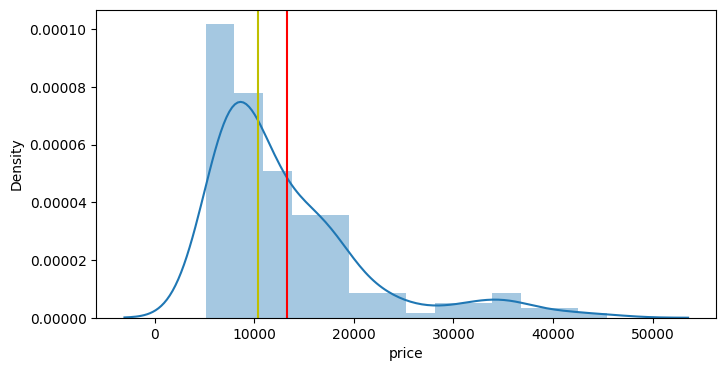

In [ ]:
mean = df['price'].mean()
median = df['price'].median()
plt.figure(figsize=[8,4])
sns.distplot(df['price'])
plt.axvline(mean,color='r')
plt.axvline(median,color = 'y')
plt.show()

In [ ]:
mean

np.float64(13227.478048780487)

<Axes: ylabel='price'>

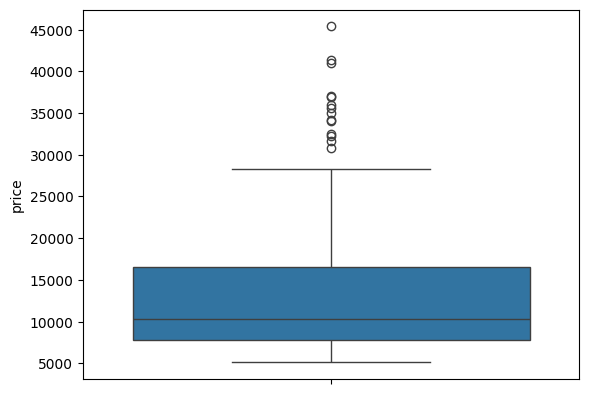

In [ ]:
sns.boxplot(df['price'])

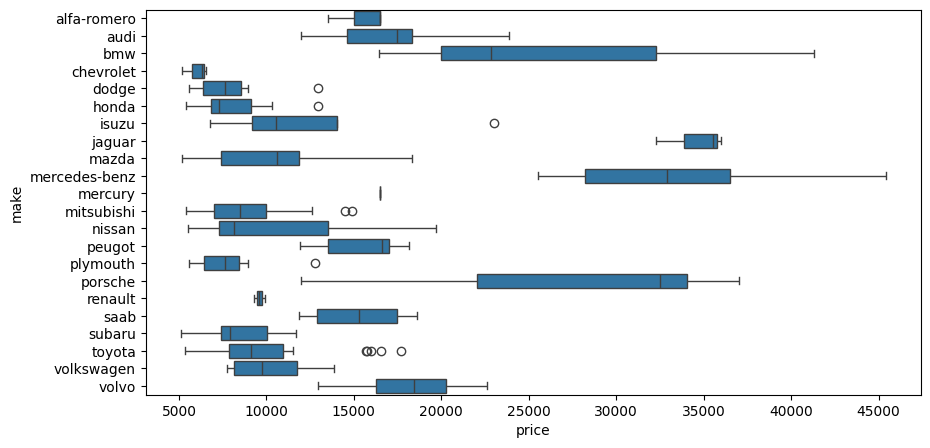

In [ ]:
plt.figure(figsize=[10,5])
sns.boxplot(data=df,y = df['make'],x=df['price'])
plt.show()

In [39]:
### findout outliers for toyota car
toyota_car_data = df[(df['make'] == 'toyota') & (df['price'] > 15000)]

# Fetching index and storing in a toyota_car_index variable
toyota_car_index = list(toyota_car_data.index)
toyota_car_index


[172, 178, 179, 180, 181]

In [40]:
# dropping outliers for toyota car
df.drop(index = toyota_car_index , inplace=True)

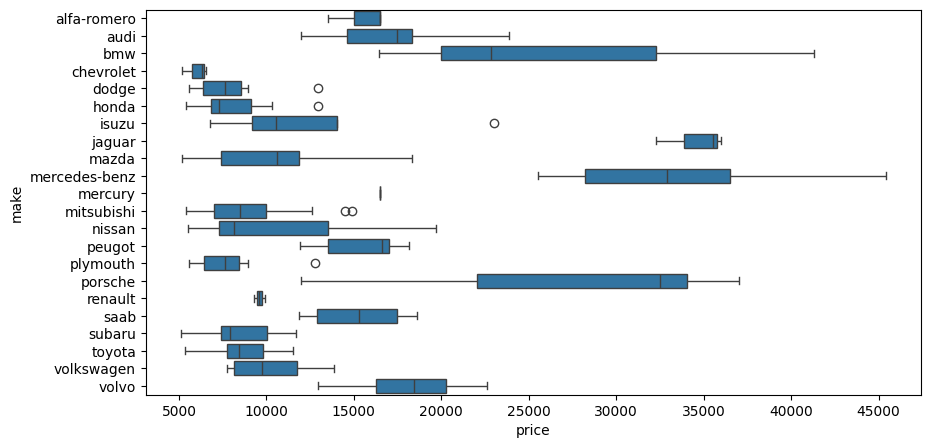

In [41]:
# checking again for outliers
plt.figure(figsize=[10,5])
sns.boxplot(data=df,y = df['make'],x=df['price'])
plt.show()

In [42]:
df.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
0,3,115.0,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111.0,21,27,13495
1,3,115.0,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111.0,21,27,16500
2,1,115.0,alfa-romero,gas,hatchback,rwd,front,65.5,52.4,ohcv,152,154.0,19,26,16500
3,2,164.0,audi,gas,sedan,fwd,front,66.2,54.3,ohc,109,102.0,24,30,13950
4,2,164.0,audi,gas,sedan,4wd,front,66.4,54.3,ohc,136,115.0,18,22,17450


### Data Encoding

- Introduction: Data encoding refers to the process of converting categorical data (non-numeric data) into numerical format so that machine learning algorithms can process them. Categorical data may represent labels, groups, or categories.

##### Common encoding methods include:

- Label Encoding: Assigning a unique integer value to each category.
- One-Hot Encoding: Creating binary columns for each category, where each column corresponds to a category and has a 1 or 0 depending on the presence of the category.
- Ordinal Encoding: Used for ordinal data, where categories have an inherent order (e.g., "low", "medium", "high").
Purpose: Data encoding is essential to convert categorical data into a numerical form that machine learning algorithms can understand and work with.

In [ ]:
'''
1. seprating df data into num_df and object_df
2. perform encoding on object_df
3. concat again both num_df and object_df
'''
print()

In [43]:
num_df = df.select_dtypes(exclude=object)

In [44]:
num_df

,symboling,normalized-losses,width,height,engine-size,horsepower,city-mpg,highway-mpg,price
0,3,115.0,64.1,48.8,130,111.0,21,27,13495
1,3,115.0,64.1,48.8,130,111.0,21,27,16500
2,1,115.0,65.5,52.4,152,154.0,19,26,16500
3,2,164.0,66.2,54.3,109,102.0,24,30,13950
4,2,164.0,66.4,54.3,136,115.0,18,22,17450
...,...,...,...,...,...,...,...,...,...
200,-1,95.0,68.9,55.5,141,114.0,23,28,16845
201,-1,95.0,68.8,55.5,141,160.0,19,25,19045
202,-1,95.0,68.9,55.5,173,134.0,18,23,21485
203,-1,95.0,68.9,55.5,145,106.0,26,27,22470


In [45]:
object_df = df.select_dtypes(include=object)

In [46]:
object_df

,make,fuel-type,body-style,drive-wheels,engine-location,engine-type
0,alfa-romero,gas,convertible,rwd,front,dohc
1,alfa-romero,gas,convertible,rwd,front,dohc
2,alfa-romero,gas,hatchback,rwd,front,ohcv
3,audi,gas,sedan,fwd,front,ohc
4,audi,gas,sedan,4wd,front,ohc
...,...,...,...,...,...,...
200,volvo,gas,sedan,rwd,front,ohc
201,volvo,gas,sedan,rwd,front,ohc
202,volvo,gas,sedan,rwd,front,ohcv
203,volvo,diesel,sedan,rwd,front,ohc


In [ ]:
# use sklearn
!pip install scikit-learn


[notice] A new release of pip is available: 24.2 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
# importing a LabelEncoder class
from sklearn.preprocessing import LabelEncoder

# object for LabelEncoder class
le = LabelEncoder()



In [48]:
le.fit_transform(object_df['make'])

array([ 0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,
        2,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,  5,  5,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  7,  7,  7,  8,
        8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  9,
        9,  9,  9,  9,  9,  9,  9, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,
       12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 14,
       14, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 16, 16, 17, 17, 17, 17,
       17, 17, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 19, 19, 19,
       19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19,
       19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20,
       20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21])

In [49]:
# Transform the data
for i in object_df.columns:
    object_df[i] = le.fit_transform(object_df[i])

In [50]:
object_df

,make,fuel-type,body-style,drive-wheels,engine-location,engine-type
0,0,1,0,2,0,0
1,0,1,0,2,0,0
2,0,1,2,2,0,5
3,1,1,3,1,0,3
4,1,1,3,0,0,3
...,...,...,...,...,...,...
200,21,1,3,2,0,3
201,21,1,3,2,0,3
202,21,1,3,2,0,5
203,21,0,3,2,0,3


In [51]:
# concate our datasets
df_new = pd.concat([num_df,object_df],axis=1)

In [52]:
df_new

,symboling,normalized-losses,width,height,engine-size,horsepower,city-mpg,highway-mpg,price,make,fuel-type,body-style,drive-wheels,engine-location,engine-type
0,3,115.0,64.1,48.8,130,111.0,21,27,13495,0,1,0,2,0,0
1,3,115.0,64.1,48.8,130,111.0,21,27,16500,0,1,0,2,0,0
2,1,115.0,65.5,52.4,152,154.0,19,26,16500,0,1,2,2,0,5
3,2,164.0,66.2,54.3,109,102.0,24,30,13950,1,1,3,1,0,3
4,2,164.0,66.4,54.3,136,115.0,18,22,17450,1,1,3,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.0,68.9,55.5,141,114.0,23,28,16845,21,1,3,2,0,3
201,-1,95.0,68.8,55.5,141,160.0,19,25,19045,21,1,3,2,0,3
202,-1,95.0,68.9,55.5,173,134.0,18,23,21485,21,1,3,2,0,5
203,-1,95.0,68.9,55.5,145,106.0,26,27,22470,21,0,3,2,0,3


#### Feature Engineering

- Feature engineering involves creating new features or modifying existing ones to improve the performance of a machine learning model. It requires domain knowledge and creativity in transforming raw data into meaningful input for models.

##### Common techniques in feature engineering include:

- Creating interaction terms: Combining features to capture interactions between them (e.g., multiplying two features together).
- Extracting features from date/time: Decomposing timestamps into day, month, year, etc.
- Polynomial features: Adding polynomial terms of features to capture nonlinear relationships.
- Aggregating features: Combining information from multiple features into one, such as calculating the mean or sum.
- Purpose: Feature engineering is essential for improving model accuracy, especially when raw data alone is insufficient for capturing complex patterns.

In [ ]:
'''
We have height and width of car and using that columns we gonna create a new feature
named as area

area = height * width
'''

df_new['area'] = df_new['height'] * df_new['width']

In [ ]:
df_new

,symboling,normalized-losses,width,height,engine-size,horsepower,city-mpg,highway-mpg,price,make,fuel-type,body-style,drive-wheels,engine-location,engine-type,area
0,3,115.0,64.1,48.8,130,111.0,21,27,13495,0,1,0,2,0,0,3128.08
1,3,115.0,64.1,48.8,130,111.0,21,27,16500,0,1,0,2,0,0,3128.08
2,1,115.0,65.5,52.4,152,154.0,19,26,16500,0,1,2,2,0,5,3432.20
3,2,164.0,66.2,54.3,109,102.0,24,30,13950,1,1,3,1,0,3,3594.66
4,2,164.0,66.4,54.3,136,115.0,18,22,17450,1,1,3,0,0,3,3605.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.0,68.9,55.5,141,114.0,23,28,16845,21,1,3,2,0,3,3823.95
201,-1,95.0,68.8,55.5,141,160.0,19,25,19045,21,1,3,2,0,3,3818.40
202,-1,95.0,68.9,55.5,173,134.0,18,23,21485,21,1,3,2,0,5,3823.95
203,-1,95.0,68.9,55.5,145,106.0,26,27,22470,21,0,3,2,0,3,3823.95


In [ ]:
# dropping column
'''
droping columns : height and width
'''

df.drop(columns = ['height','width'],axis = 1,inplace=True)

In [ ]:
df

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
0,3,115.0,alfa-romero,gas,convertible,rwd,front,dohc,130,111.0,21,27,13495
1,3,115.0,alfa-romero,gas,convertible,rwd,front,dohc,130,111.0,21,27,16500
2,1,115.0,alfa-romero,gas,hatchback,rwd,front,ohcv,152,154.0,19,26,16500
3,2,164.0,audi,gas,sedan,fwd,front,ohc,109,102.0,24,30,13950
4,2,164.0,audi,gas,sedan,4wd,front,ohc,136,115.0,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.0,volvo,gas,sedan,rwd,front,ohc,141,114.0,23,28,16845
201,-1,95.0,volvo,gas,sedan,rwd,front,ohc,141,160.0,19,25,19045
202,-1,95.0,volvo,gas,sedan,rwd,front,ohcv,173,134.0,18,23,21485
203,-1,95.0,volvo,diesel,sedan,rwd,front,ohc,145,106.0,26,27,22470


### Feature Scaling

- Feature scaling refers to the process of adjusting the range of features in a dataset so that they have similar magnitudes, which is particularly important for models that rely on distance metrics or optimization algorithms.

- Normalization (Min-Max Scaling): Rescaling the features to a specific range, typically [0, 1], to ensure that all features contribute equally to the model.

Formula: Xscaled = (Xold - Xmin)/(Xmax-Xmin)

- Standardization (Z-score Scaling): Scaling features so that they have a mean of 0 and a standard deviation of 1, which ensures the data is centered around 0.

Formula:

X_scaled = (X - X_mean) / X_std


In [ ]:
# import Standarscaler
from sklearn.preprocessing import StandardScaler

# create instance for StandardScaler
ss = StandardScaler()

# transform it
ss.fit_transform(df_new)

array([[ 1.77921923, -0.15915926, -0.82735309, ..., -0.12340351,
        -3.15592174, -1.83209504],
       [ 1.77921923, -0.15915926, -0.82735309, ..., -0.12340351,
        -3.15592174, -1.83209504],
       [ 0.14315557, -0.15915926, -0.17863042, ..., -0.12340351,
         1.97565832, -0.48710007],
       ...,
       [-1.49290809, -0.80222696,  1.39683892, ..., -0.12340351,
         1.97565832,  1.24544558],
       [-1.49290809, -0.80222696,  1.39683892, ..., -0.12340351,
        -0.0769737 ,  1.24544558],
       [-1.49290809, -0.80222696,  1.39683892, ..., -0.12340351,
        -0.0769737 ,  1.24544558]])

### Data Encoding

In [ ]:
df['fuel-type'].unique()

array(['gas', 'diesel'], dtype=object)

In [ ]:
df.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
0,3,115.0,alfa-romero,gas,convertible,rwd,front,dohc,130,111.0,21,27,13495
1,3,115.0,alfa-romero,gas,convertible,rwd,front,dohc,130,111.0,21,27,16500
2,1,115.0,alfa-romero,gas,hatchback,rwd,front,ohcv,152,154.0,19,26,16500
3,2,164.0,audi,gas,sedan,fwd,front,ohc,109,102.0,24,30,13950
4,2,164.0,audi,gas,sedan,4wd,front,ohc,136,115.0,18,22,17450


In [ ]:
# Dummy variable
pd.get_dummies(df['fuel-type'])

,diesel,gas
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True
...,...,...
200,False,True
201,False,True
202,False,True
203,True,False


In [ ]:
!pip install scikit-learn

In [ ]:
# one hot encoding
# importing a class
from sklearn.preprocessing import OneHotEncoder

# instance(object) of class
encoder = OneHotEncoder(sparse_output=False)

# transform the data

In [ ]:
p = encoder.fit_transform(df[['fuel-type']])
pd.DataFrame(p)

,0,1
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
...,...,...
195,0.0,1.0
196,0.0,1.0
197,0.0,1.0
198,1.0,0.0


In [ ]:
df.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
0,3,115.0,alfa-romero,gas,convertible,rwd,front,dohc,130,111.0,21,27,13495
1,3,115.0,alfa-romero,gas,convertible,rwd,front,dohc,130,111.0,21,27,16500
2,1,115.0,alfa-romero,gas,hatchback,rwd,front,ohcv,152,154.0,19,26,16500
3,2,164.0,audi,gas,sedan,fwd,front,ohc,109,102.0,24,30,13950
4,2,164.0,audi,gas,sedan,4wd,front,ohc,136,115.0,18,22,17450


In [ ]:
cat_df = df.select_dtypes(include='object')
num_df = df.select_dtypes(exclude='object')

In [ ]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

# instance of class
label_encoder = LabelEncoder()

# transform

# df['fuel-type'] = label_encoder.fit_transform(df['fuel-type'])

for col in cat_df.columns:
    df[col] = label_encoder.fit_transform(df[col])

In [ ]:
cat_df

,make,fuel-type,body-style,drive-wheels,engine-location,engine-type
0,0,1,0,2,0,0
1,0,1,0,2,0,0
2,0,1,2,2,0,5
3,1,1,3,1,0,3
4,1,1,3,0,0,3
...,...,...,...,...,...,...
200,21,1,3,2,0,3
201,21,1,3,2,0,3
202,21,1,3,2,0,5
203,21,0,3,2,0,3


In [ ]:
num_df

,symboling,normalized-losses,engine-size,horsepower,city-mpg,highway-mpg,price
0,3,115.0,130,111.0,21,27,13495
1,3,115.0,130,111.0,21,27,16500
2,1,115.0,152,154.0,19,26,16500
3,2,164.0,109,102.0,24,30,13950
4,2,164.0,136,115.0,18,22,17450
...,...,...,...,...,...,...,...
200,-1,95.0,141,114.0,23,28,16845
201,-1,95.0,141,160.0,19,25,19045
202,-1,95.0,173,134.0,18,23,21485
203,-1,95.0,145,106.0,26,27,22470


In [ ]:
new_df = pd.concat([cat_df,num_df],axis=1)

,make,fuel-type,body-style,drive-wheels,engine-location,engine-type,symboling,normalized-losses,engine-size,horsepower,city-mpg,highway-mpg,price
0,0,1,0,2,0,0,3,115.0,130,111.0,21,27,13495
1,0,1,0,2,0,0,3,115.0,130,111.0,21,27,16500
2,0,1,2,2,0,5,1,115.0,152,154.0,19,26,16500
3,1,1,3,1,0,3,2,164.0,109,102.0,24,30,13950
4,1,1,3,0,0,3,2,164.0,136,115.0,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,21,1,3,2,0,3,-1,95.0,141,114.0,23,28,16845
201,21,1,3,2,0,3,-1,95.0,141,160.0,19,25,19045
202,21,1,3,2,0,5,-1,95.0,173,134.0,18,23,21485
203,21,0,3,2,0,3,-1,95.0,145,106.0,26,27,22470
